# Valuación de Opciones Americanas con Aprendizaje Estadístico

### Correcciones aplicadas:
1. **Tasa de descuento**: `r_t = r * dt` en lugar de `r / T` (pasos)
2. **Inducción hacia atrás en LSM-SVR**: usa `cash_flows` ya actualizados
3. **Lógica ITM corregida**: usa precio del subyacente `S0`, no `lastPrice` de la opción
4. **Semilla aleatoria**: derivada deterministamente de `symbol + optionType + strike`
5. **Variable global `num_paths`**: reemplazada por `paths.shape[0]`
6. **Validaciones `sigma <= 0`**: en Black-Scholes y árbol binomial
7. **Tiempo al vencimiento real**: cada opción usa su `T_real` calculado desde `lastTradeDate`


## 1. Librerías

In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import kagglehub
import os
import shutil
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import date
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression
from scipy import stats
from scipy.stats import norm


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Funciones

In [2]:
def tasa_libre_riesgo(start_date, end_date):
    """
    Tasa libre de riesgo usando bono del Tesoro EE.UU. a 10 años (^TNX).
    Retorna float en decimal (ej. 0.035 para 3.5%).
    """
    tnx = yf.Ticker('^TNX')
    historial = tnx.history(start=start_date, end=end_date)
    return historial['Close'].iloc[-1] / 100


In [3]:
def tasa_ret_anual_precio_act(lista, start_date, end_date):
    """
    Precio actual y drift anualizado para una lista de activos.
    Retorna pd.DataFrame con columnas ['symbol', 'S0', 'mu'].
    """
    if not isinstance(lista, list):
        lista = [lista]
    df = pd.DataFrame(columns=['symbol', 'S0', 'mu'])
    for i in lista:
        ticker = yf.Ticker(i)
        price  = ticker.history(period='1d')['Close'].iloc[0]
        data   = ticker.history(start=start_date, end=end_date).reset_index()
        retorn = pd.DataFrame({'Date': data['Date'], 'Price': data['Close']})
        retorn['Log_Returns'] = np.log(retorn['Price'] / retorn['Price'].shift(1))
        drift  = retorn['Log_Returns'].mean() * 252
        df.loc[len(df)] = [i, price, drift]
    return df


In [4]:
def obtener_opciones(portfolio, start_date, end_date, inf_portfolio):
    """
    Obtiene opciones calls y puts para un portafolio via yfinance.
    ITM usando S0 del subyacente (no lastPrice de la opción).
    Excluye impliedVolatility <= 0.
    """
    if not isinstance(portfolio, list):
        portfolio = [portfolio]
    df_list = []
    for symbol in portfolio:
        ticker  = yf.Ticker(symbol)
        options = ticker.option_chain()
        df_calls = options.calls.copy(); df_calls['optionType'] = 'calls'
        df_puts  = options.puts.copy();  df_puts['optionType']  = 'puts'
        df = pd.concat([df_calls, df_puts], ignore_index=True)
        df['lastTradeDate'] = pd.to_datetime(df['lastTradeDate'])
        df = df[(df['lastTradeDate'] >= start_date) & (df['lastTradeDate'] <= end_date)]
        S0 = inf_portfolio.loc[inf_portfolio['symbol'] == symbol, 'S0'].values[0]
        df['inTheMoney'] = df.apply(
            lambda row: (row['optionType'] == 'calls' and S0 > row['strike']) or
                        (row['optionType'] == 'puts'  and S0 < row['strike']), axis=1)
        df = df[(df['inTheMoney'] == True) &
                (df['impliedVolatility'] > 0) &
                (df['impliedVolatility'] < 3)]
        df['symbol']    = symbol
        df['shortDate'] = df['lastTradeDate'].dt.strftime('%Y-%m-%d')
        df_list.append(df)
    return pd.concat(df_list, ignore_index=True).reset_index(drop=True)


In [5]:
def condicional(symbol, option_type, strike, inf_portfolio):
    """Valor intrínseco: max(S0-K,0) para calls, max(K-S0,0) para puts."""
    S0 = inf_portfolio.loc[inf_portfolio['symbol'] == symbol, 'S0'].values[0]
    return max(S0 - strike, 0) if option_type == 'calls' else max(strike - S0, 0)


In [6]:
def dias_al_vencimiento(last_trade_date, T_default=1.0):
    """
    T en años desde hoy hasta la fecha de vencimiento.
    Mínimo 1 día para evitar T=0.
    """
    try:
        fecha = last_trade_date.date() if hasattr(last_trade_date, 'date') else pd.to_datetime(last_trade_date).date()
        return max((fecha - date.today()).days, 1) / 365
    except Exception:
        return T_default


In [7]:
def simulate_gbm(mu, sigma, s0, T, dt, num_paths, seed=None):
    """
    Geometric Brownian Motion.
    seed: derivada de symbol+optionType+strike para replicabilidad única por opción.
    """
    if seed is not None:
        np.random.seed(seed)
    num_steps = int(T / dt) + 1
    times = np.linspace(0, T, num_steps)
    paths = np.zeros((num_paths, num_steps))
    paths[:, 0] = s0
    for i in range(num_paths):
        dW = np.random.normal(0, np.sqrt(dt), num_steps - 1)
        paths[i, 1:] = s0 * np.exp(
            (mu - 0.5 * sigma**2) * times[1:] + sigma * np.cumsum(dW))
    return paths


In [8]:
def longstaff_schwartz(paths, strike, r, T_years, option_type, symbol, graphics=False):
    """
    LSM con SVR (kernel RBF).
    Correcciones: r_t=r*dt, cash_flows actualizados, sin variable global num_paths.
    """
    num_sim, num_steps = paths.shape
    T_steps = num_steps - 1
    r_t     = r * (T_years / T_steps)

    exercise_times, exercise_prices = [], []
    continuation_times, continuation_prices = [], []

    cash_flows = (np.maximum(paths - strike, 0) if option_type == 'calls'
                  else np.maximum(strike - paths, 0)).astype(float)

    for t in range(T_steps, 0, -1):
        itm = paths[:, t-1] > strike if option_type == 'calls' else paths[:, t-1] < strike
        if itm.sum() > 0:
            X = paths[itm, t-1].reshape(-1, 1)
            Y = cash_flows[itm, t] * np.exp(-r_t)
            model = SVR(kernel='rbf', C=1e1, gamma=0.1).fit(X, Y)
            continuations = np.zeros(num_sim)
            continuations[itm] = model.predict(X)
        else:
            continuations = np.zeros(num_sim)
        cash_flows[:, t] = np.where(continuations > cash_flows[:, t], 0, cash_flows[:, t])
        exercised = continuations < cash_flows[:, t]
        cash_flows[:, :t][exercised] = 0
        if graphics:
            for i in range(num_sim):
                if exercised[i]:
                    exercise_times.append(t); exercise_prices.append(paths[i, t])
                else:
                    continuation_times.append(t); continuation_prices.append(paths[i, t])

    decision        = pd.DataFrame(cash_flows)
    option_val_idx  = decision.idxmax(axis=1)
    vector_valuation = pd.DataFrame(option_val_idx).T
    opt_nonzero      = option_val_idx[option_val_idx != 0]
    option_valuation = opt_nonzero.mode().iloc[0] if not opt_nonzero.empty else 0

    final_cfs = pd.DataFrame({'price': cash_flows.max(axis=1), 'exercise': option_val_idx})
    final_cfs['present_value'] = final_cfs['price'] / np.exp(r_t * final_cfs['exercise'])
    option_price = final_cfs['present_value'].mean()
    se = final_cfs['present_value'].std(ddof=1) / np.sqrt(num_sim)
    z  = stats.norm.ppf(0.975)

    if graphics:
        t_axis = np.linspace(0, 1, num_steps)
        fig, ax = plt.subplots(figsize=(10, 6))
        for i in range(num_sim): ax.plot(t_axis, paths[i, :])
        ax.set_title(f'Trayectorias GBM — {symbol}'); ax.grid(True); plt.show()
        fig, ax = plt.subplots(figsize=(8, 5))
        sns.boxplot(data=final_cfs['present_value'], ax=ax)
        ax.set_title(f'Distribución del precio — {option_type} ({symbol})'); plt.show()
        if len(exercise_times) > 0:
            fig, ax = plt.subplots(figsize=(10, 6))
            ax.plot(np.array(exercise_times)/T_steps,    exercise_prices,    'rx', label='Ejercicio')
            ax.plot(np.array(continuation_times)/T_steps, continuation_prices, '.', color='grey', label='Continuación')
            ax.legend(); ax.set_title(f'Ejercicio vs Continuación — {option_type}'); ax.grid(True); plt.show()
        first_ex = np.argmax(cash_flows != 0, axis=1)
        plt.figure(figsize=(10, 6))
        for i in range(num_sim):
            idx = first_ex[i]
            plt.plot(t_axis[:idx+1], paths[i, :idx+1], color='lightgray')
            plt.plot(t_axis[idx:],   paths[i, idx:],   color='darkgray', linestyle='--')
            if idx < len(t_axis): plt.plot(t_axis[idx], paths[i, idx], 'rx')
        plt.title(f'Trayectorias con primer ejercicio — {option_type}'); plt.grid(True); plt.show()

    return option_price, option_price - z*se, option_price + z*se, option_valuation, vector_valuation


In [9]:
def black_scholes(option_type, S0, K, T, r, sigma):
    """Black-Scholes europeo. Si sigma<=0 retorna valor intrínseco descontado."""
    if sigma <= 0:
        return max(S0-K*np.exp(-r*T),0) if option_type.lower()=='calls' else max(K*np.exp(-r*T)-S0,0)
    d1 = (np.log(S0/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    if option_type.lower() == 'calls':
        return S0*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)
    return K*np.exp(-r*T)*norm.cdf(-d2) - S0*norm.cdf(-d1)


In [10]:
def american_option_monte_carlo(paths, K, T, r, option_type='puts'):
    """Monte Carlo americano con ejercicio anticipado (LSM + OLS cuadrático)."""
    num_paths_n, num_steps = paths.shape
    r_dt = r * (T / (num_steps - 1))
    cash_flows = (np.maximum(K-paths[:,-1],0) if option_type=='puts'
                  else np.maximum(paths[:,-1]-K,0)).astype(float)
    for t in range(num_steps-2, 0, -1):
        exercise = np.maximum(K-paths[:,t],0) if option_type=='puts' else np.maximum(paths[:,t]-K,0)
        itm = exercise > 0
        if itm.sum() < 2: cash_flows *= np.exp(-r_dt); continue
        X = paths[itm, t].reshape(-1, 1)
        Y = cash_flows[itm] * np.exp(-r_dt)
        cont = LinearRegression().fit(np.hstack([X, X**2]), Y).predict(np.hstack([X, X**2]))
        ex_now = np.zeros(num_paths_n, dtype=bool)
        ex_now[itm] = exercise[itm] > cont
        cash_flows[ex_now]  = exercise[ex_now]
        cash_flows[~ex_now] *= np.exp(-r_dt)
    return np.mean(cash_flows) * np.exp(-r_dt)


In [11]:
def binomial_tree_american_option(S0, K, T, r, sigma, n, option_type='calls'):
    """Árbol binomial CRR. Si sigma<=0 o p fuera de (0,1) retorna valor intrínseco."""
    if sigma <= 0:
        return max(S0-K*np.exp(-r*T),0) if option_type=='calls' else max(K*np.exp(-r*T)-S0,0)
    dt = T/n; u = np.exp(sigma*np.sqrt(dt)); d = np.exp(-sigma*np.sqrt(dt))
    p  = (np.exp(r*dt)-d)/(u-d)
    if not (0 < p < 1):
        return max(S0-K*np.exp(-r*T),0) if option_type=='calls' else max(K*np.exp(-r*T)-S0,0)
    prices = np.zeros((n+1,n+1))
    option_values = np.zeros((n+1,n+1))
    for i in range(n+1): prices[i,0] = S0*(u**i)*(d**(n-i))
    for i in range(n+1):
        option_values[i,n] = max(0,prices[i,n]-K) if option_type=='calls' else max(0,K-prices[i,n])
    for j in range(n-1,-1,-1):
        for i in range(j+1):
            hold = np.exp(-r*dt)*(p*option_values[i,j+1]+(1-p)*option_values[i+1,j+1])
            ex   = max(0,prices[i,j]-K) if option_type=='calls' else max(0,K-prices[i,j])
            option_values[i,j] = max(ex, hold)
    return option_values[0,0]


In [12]:
def longstaff_schwartz_polinomios(paths, strike, r, T_years, option_type, poly_degree=2):
    """LSM con regresión polinómica de grado configurable. r_t = r * dt_sim."""
    num_steps = paths.shape[1]
    T_steps   = num_steps - 1
    r_t       = r * (T_years / T_steps)
    cash_flows = (np.maximum(paths-strike,0) if option_type=='calls'
                  else np.maximum(strike-paths,0)).astype(float)
    for t in range(T_steps, 0, -1):
        itm = paths[:,t-1] > strike if option_type=='calls' else paths[:,t-1] < strike
        if np.any(itm):
            X      = paths[itm, t-1]
            X_poly = np.column_stack([X**i for i in range(1, poly_degree+1)])
            Y      = cash_flows[itm, t] * np.exp(-r_t)
            cont   = LinearRegression().fit(X_poly, Y).predict(X_poly)
            continuations = np.zeros(paths.shape[0])
            continuations[itm] = cont
        else:
            continuations = np.zeros(paths.shape[0])
        cash_flows[:,t] = np.where(continuations > cash_flows[:,t], 0, cash_flows[:,t])
        exercised = continuations < cash_flows[:,t]
        cash_flows[:,:t][exercised] = 0
    exercise_times = pd.DataFrame(cash_flows).idxmax(axis=1)
    final_cfs = pd.DataFrame({'price': cash_flows.max(axis=1), 'exercise': exercise_times})
    final_cfs['present_value'] = final_cfs['price'] / np.exp(r_t * final_cfs['exercise'])
    return final_cfs['present_value'].mean()


In [13]:
def price_value_op(
    symbol,
    optionType,
    strike,
    impliedVolatility,
    underlyingPrice,
    T,
    dt,
    num_paths,
    rateRiskFree,
    inf_portfolio,
    graphics=False
):
    """
    Calcula precio con:
    - LSM-SVR
    - Black-Scholes
    - Monte Carlo
    - Binomial
    - LSP2
    - LSP3
    """

    mu = inf_portfolio.loc[
        inf_portfolio['symbol'] == symbol,
        'mu'
    ].values[0]

    seed = abs(hash(f'{symbol}_{optionType}_{strike}')) % (2**32)

    # Simulación GBM del SUBYACENTE
    paths = simulate_gbm(
        mu,
        impliedVolatility,
        underlyingPrice,
        T,
        dt,
        num_paths,
        seed=seed
    )

    op, lo, hi, ov, vv = longstaff_schwartz(
        paths,
        strike,
        rateRiskFree,
        T,
        optionType,
        symbol,
        graphics
    )

    bs = black_scholes(
        optionType,
        underlyingPrice,
        strike,
        T,
        rateRiskFree,
        impliedVolatility
    )

    mc = american_option_monte_carlo(
        paths,
        strike,
        T,
        rateRiskFree,
        optionType
    )

    bn = binomial_tree_american_option(
        underlyingPrice,
        strike,
        T,
        rateRiskFree,
        impliedVolatility,
        max(int(T / dt), 1),
        optionType
    )

    lp2 = longstaff_schwartz_polinomios(
        paths,
        strike,
        rateRiskFree,
        T,
        optionType,
        poly_degree=2
    )

    lp3 = longstaff_schwartz_polinomios(
        paths,
        strike,
        rateRiskFree,
        T,
        optionType,
        poly_degree=3
    )

    return op, lo, hi, ov, bs, mc, bn, lp2, lp3, vv

In [14]:
def obtain_option_values(
    row,
    T,
    dt,
    num_paths,
    rateRiskFree,
    inf_portfolio,
    graphics=False
):

    T_real = dias_al_vencimiento(
        row['expirationDate'],
        T_default=T
    )

    T_real = max(T_real, dt)

    # Validaciones críticas
    if (
        pd.isna(row['underlyingPrice']) or
        pd.isna(row['impliedVolatility']) or
        pd.isna(row['strike']) or
        row['underlyingPrice'] <= 0 or
        row['impliedVolatility'] <= 0 or
        row['strike'] <= 0
    ):
        return pd.Series(
            [np.nan]*9 + [[0]*num_paths]
        )

    try:

        op,lo,hi,ov,bs,mc,bn,lp2,lp3,vv = price_value_op(
            row['symbol'],
            row['optionType'],
            row['strike'],
            row['impliedVolatility'],
            row['underlyingPrice'],
            T_real,
            dt,
            num_paths,
            rateRiskFree,
            inf_portfolio,
            graphics
        )

        if isinstance(vv, pd.DataFrame):
            vv = vv.iloc[0].tolist()

        elif isinstance(vv, pd.Series):
            vv = vv.tolist()

        elif not isinstance(vv, list):
            vv = list(vv)

        vv = (vv + [0]*num_paths)[:num_paths]

        return pd.Series([
            op,lo,hi,ov,bs,mc,bn,lp2,lp3
        ] + vv)

    except Exception as e:

        print(
            f'Error en {row["symbol"]} '
            f'{row["optionType"]} '
            f'K={row["strike"]}: {e}'
        )

        return pd.Series(
            [np.nan]*9 + [[0]*num_paths]
        )

In [15]:
def agregar_valuaciones(
    df,
    T,
    dt,
    num_paths,
    rateRiskFree,
    inf_portfolio,
    graphics=False
):
    """
    Aplica obtain_option_values a todo el DataFrame
    y concatena columnas.
    """

    new_cols = df.apply(
        obtain_option_values,
        axis=1,
        T=T,
        dt=dt,
        num_paths=num_paths,
        rateRiskFree=rateRiskFree,
        inf_portfolio=inf_portfolio,
        graphics=graphics,
        result_type='expand'
    )

    n_vec = max(len(new_cols.columns) - 9, 0)

    new_cols.columns = [
        'optionPrice',
        'lowerInterval',
        'upperInterval',
        'optionValuation',
        'black_scholes_price',
        'monte_carlo_price',
        'binomial_price',
        'lsp2_price',
        'lsp3_price'
    ] + [f'vector_valuation_{i}' for i in range(n_vec)]

    return pd.concat([df, new_cols], axis=1)

In [16]:
def graficar_comparativa(df_eval, metodos, etiquetas, titulo=''):
    """Gráficas MAE, MAPE, boxplot y scatter para cualquier DataFrame evaluado."""
    cmap    = ['#2ecc71','#3498db','#9b59b6','#e67e22','#e74c3c','#1abc9c']
    labels  = [etiquetas[c] for c in metodos]
    colores = ['#2ecc71' if c=='optionPrice' else '#95a5a6' for c in metodos]

    # Barras MAE y MAPE
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, vals, ylabel, t in zip(axes,
        [[df_eval[f'ae_{c}'].mean() for c in metodos],[df_eval[f'pct_{c}'].mean() for c in metodos]],
        ['MAE (USD)','MAPE (%)'],['MAE por método','MAPE por método']):
        bars = ax.bar(labels, vals, color=colores, edgecolor='white')
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                    f'{val:.3f}', ha='center', va='bottom', fontsize=8)
        ax.set_title(t, fontsize=11, fontweight='bold'); ax.set_ylabel(ylabel)
        ax.set_xticklabels(labels, rotation=30, ha='right', fontsize=9)
        ax.grid(axis='y', linestyle='--', alpha=0.5)
    plt.suptitle(titulo, fontsize=12, fontweight='bold'); plt.tight_layout(); plt.show()

    # Scatter estimado vs real
    fig, axes = plt.subplots(2, 3, figsize=(15, 9)); axes = axes.flatten()
    for idx, (col, color) in enumerate(zip(metodos, cmap)):
        ax = axes[idx]
        ax.scatter(df_eval['lastPrice'], df_eval[col], alpha=0.4, color=color, edgecolors='white', s=25)
        lim = [min(df_eval['lastPrice'].min(),df_eval[col].min())*0.95,
               max(df_eval['lastPrice'].max(),df_eval[col].max())*1.05]
        ax.plot(lim, lim, 'k--', linewidth=1)
        ax.set_title(f'{etiquetas[col]}\nMAE={df_eval[f"ae_{col}"].mean():.3f}  MAPE={df_eval[f"pct_{col}"].mean():.2f}%',
                     fontsize=9, fontweight='bold')
        ax.set_xlabel('Precio real (USD)', fontsize=8); ax.set_ylabel('Precio estimado (USD)', fontsize=8)
        ax.grid(True, linestyle='--', alpha=0.4)
    plt.suptitle(f'Precio estimado vs real — {titulo}', fontsize=12, fontweight='bold', y=1.01)
    plt.tight_layout(); plt.show()

    # Boxplot
    fig, ax = plt.subplots(figsize=(12, 5))
    bp = ax.boxplot([df_eval[f'ae_{c}'].values for c in metodos], patch_artist=True,
                    medianprops=dict(color='black', linewidth=2))
    for patch, color in zip(bp['boxes'], cmap): patch.set_facecolor(color); patch.set_alpha(0.75)
    ax.set_xticklabels(labels, rotation=30, ha='right', fontsize=9)
    ax.set_title('Distribución del error absoluto por método', fontsize=11, fontweight='bold')
    ax.set_ylabel('Error absoluto (USD)'); ax.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout(); plt.show()


## 3. Datos históricos reales — Kaggle

### Por qué Kaggle
Permite comparar los modelos contra **precios reales históricos de mercado** (no solo entre métodos),
lo cual es el estándar más riguroso para una tesis metodológica.

### Datasets utilizados

| Ticker | Periodo | Dataset |
|---|---|---|
| AAPL | 2016–2023 | `kylegraupe/aapl-options-data-2016-2020` |
| SPY | 2019–2022 | `kylegraupe/spy-daily-eod-options-quotes-2020-2022` |
| QQQ | 2020–2022 | `kylegraupe/qqq-daily-option-chains-q1-2020-to-q4-2022` |
| TSLA | 2019–2022 | `kylegraupe/tsla-daily-eod-options-quotes-2019-2022` |

### Requisito
```bash
pip install kagglehub
```
La primera vez que descargues, kagglehub abrirá el navegador para autenticarte con tu cuenta de Kaggle.

### Ventajas vs yfinance
| Aspecto | yfinance | Kaggle |
|---|---|---|
| Precios históricos reales de opciones | ❌ | ✅ |
| Comparación vs mercado real | ❌ | ✅ |
| Volatilidad sin circularidad BS | ❌ | ✅ |
| Cobertura temporal | Solo hoy | 2016–2023 |

### Formato de columnas (kylegraupe)
| Columna | Descripción |
|---|---|
| `QUOTE_DATE` | Fecha de cotización (`lastTradeDate`) |
| `EXPIRE_DATE` | Fecha de vencimiento |
| `STRIKE` | Precio de ejercicio |
| `C_P` | `C`=call, `P`=put |
| `LAST` | Último precio de la opción (`lastPrice`) |
| `IV` | Volatilidad implícita (se reemplaza con vol histórica) |
| `UNDERLYING_LAST` | Precio del subyacente en esa fecha |


In [17]:
CARPETA_DATOS = '/Users/leohdezj/Personal/GitHub/Tesis/Datos'
os.makedirs(CARPETA_DATOS, exist_ok=True)

# IDs de los datasets en Kaggle
KAGGLE_DATASETS = {
    'AAPL': 'kylegraupe/aapl-options-data-2016-2020',
    'SPY':  'kylegraupe/spy-daily-eod-options-quotes-2020-2022',
    'QQQ':  'kylegraupe/qqq-daily-option-chains-q1-2020-to-q4-2022',
    'TSLA': 'kylegraupe/tsla-daily-eod-options-quotes-2019-2022'
}


In [18]:
def descargar_kaggle(symbol, carpeta=CARPETA_DATOS):
    """
    Descarga el dataset de Kaggle para un símbolo y lo copia a CARPETA_DATOS.
    Usa caché local si ya fue descargado.
    La primera vez abre el navegador para autenticarse con Kaggle.
    """
    destino = os.path.join(carpeta, f'{symbol.lower()}_options.csv')

    if os.path.exists(destino):
        print(f'  Caché: {destino}')
        return destino

    dataset_id = KAGGLE_DATASETS.get(symbol.upper())
    if not dataset_id:
        raise ValueError(f'Dataset no configurado para {symbol}. Agrega el ID en KAGGLE_DATASETS.')

    print(f'Descargando {symbol} desde Kaggle...')
    path = kagglehub.dataset_download(dataset_id)

    # Buscar el CSV descargado
    archivos_csv = [f for f in os.listdir(path) if f.endswith('.csv')]
    if not archivos_csv:
        raise FileNotFoundError(f'No se encontró CSV en {path}. Archivos: {os.listdir(path)}')

    # Copiar a CARPETA_DATOS
    origen = os.path.join(path, archivos_csv[0])
    shutil.copy2(origen, destino)
    print(f'  Guardado en: {destino}')
    return destino


In [19]:
def cargar_kaggle_options(symbol, carpeta=CARPETA_DATOS):
    """
    Descarga (si es necesario) y carga el CSV de opciones de Kaggle,
    normalizándolo al formato del pipeline.

    Retorna: pd.DataFrame normalizado.
    """

    ruta = descargar_kaggle(symbol, carpeta)

    df = pd.read_csv(ruta, low_memory=False)

    # Limpiar nombres de columnas
    df.columns = (
        df.columns
        .str.strip()
        .str.upper()
        .str.replace('[', '', regex=False)
        .str.replace(']', '', regex=False)
    )


    # =========================
    # Construir CALLS
    # =========================
    calls = pd.DataFrame({
        'lastTradeDate': df['QUOTE_DATE'],
        'expirationDate': df['EXPIRE_DATE'],
        'strike': df['STRIKE'],
        'optionType': 'calls',
        'lastPrice': df['C_LAST'],
        'impliedVolatility': df['C_IV'],
        'underlyingPrice': df['UNDERLYING_LAST'],
        'volume': df.get('C_VOLUME'),
        'bid': df.get('C_BID'),
        'ask': df.get('C_ASK'),
        'delta': df.get('C_DELTA'),
        'gamma': df.get('C_GAMMA'),
        'theta': df.get('C_THETA'),
        'vega': df.get('C_VEGA'),
        'rho': df.get('C_RHO'),
    })

    # =========================
    # Construir PUTS
    # =========================
    puts = pd.DataFrame({
        'lastTradeDate': df['QUOTE_DATE'],
        'expirationDate': df['EXPIRE_DATE'],
        'strike': df['STRIKE'],
        'optionType': 'puts',
        'lastPrice': df['P_LAST'],
        'impliedVolatility': df['P_IV'],
        'underlyingPrice': df['UNDERLYING_LAST'],
        'volume': df.get('P_VOLUME'),
        'bid': df.get('P_BID'),
        'ask': df.get('P_ASK'),
        'delta': df.get('P_DELTA'),
        'gamma': df.get('P_GAMMA'),
        'theta': df.get('P_THETA'),
        'vega': df.get('P_VEGA'),
        'rho': df.get('P_RHO'),
    })

    # Unir calls + puts
    df = pd.concat([calls, puts], ignore_index=True)

    # =========================
    # Normalizar tipos
    # =========================
    df['lastTradeDate'] = pd.to_datetime(
        df['lastTradeDate'],
        errors='coerce'
    )

    df['expirationDate'] = pd.to_datetime(
        df['expirationDate'],
        errors='coerce'
    )

    columnas_numericas = [
        'strike',
        'lastPrice',
        'impliedVolatility',
        'underlyingPrice',
        'volume',
        'bid',
        'ask',
        'delta',
        'gamma',
        'theta',
        'vega',
        'rho'
    ]

    for col in columnas_numericas:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    # Agregar símbolo
    df['symbol'] = symbol.upper()

    # Fecha corta
    df['shortDate'] = df['lastTradeDate'].dt.strftime('%Y-%m-%d')

    # Limpiar filas inválidas
    df = df.dropna(
        subset=[
            'lastTradeDate',
            'expirationDate',
            'strike',
            'lastPrice'
        ]
    )

    print(
        f'{symbol.upper()}: {len(df):,} registros | '
        f'{df["lastTradeDate"].min().date()} → '
        f'{df["lastTradeDate"].max().date()}'
    )

    return df.reset_index(drop=True)

In [20]:
def calcular_vol_historica_yf(symbol, fecha_valuacion, ventana=30):
    """
    Volatilidad histórica anualizada sin look-ahead bias usando yfinance.
    Elimina la circularidad con Black-Scholes que tiene la IV del CSV.
    """
    fecha_dt    = pd.to_datetime(fecha_valuacion)
    fecha_inicio = (fecha_dt - pd.Timedelta(days=ventana*3)).strftime('%Y-%m-%d')
    hist = yf.Ticker(symbol).history(start=fecha_inicio, end=fecha_valuacion)
    if hist.empty or len(hist) < 5:
        return None
    log_ret = np.log(hist['Close'] / hist['Close'].shift(1)).dropna()
    sigma   = float(log_ret.tail(ventana).std() * np.sqrt(252))
    return sigma if sigma > 0 else None


In [21]:
def filtrar_kaggle(df, start_date, end_date, option_type=None,
                   usar_vol_historica=True, ventana_vol=30):
    """
    Filtra el DataFrame de Kaggle y aplica:
    - Rango de fechas
    - Tipo de opción
    - ITM usando underlyingPrice real de esa fecha (sin look-ahead)
    - Vol histórica desde yfinance (sin circularidad con BS)
    - Filtros de calidad: lastPrice>0, 0<IV<3
    """
    df = df.copy()
    df = df[(df['lastTradeDate'] >= pd.to_datetime(start_date)) &
            (df['lastTradeDate'] <= pd.to_datetime(end_date))]
    if option_type:
        df = df[df['optionType'] == option_type]

    # ITM con precio real del subyacente en esa fecha
    if 'underlyingPrice' in df.columns:
        df['inTheMoney'] = df.apply(
            lambda row: (
                (row['optionType']=='calls' and row['underlyingPrice'] > row['strike']) or
                (row['optionType']=='puts'  and row['underlyingPrice'] < row['strike'])
            ) if pd.notna(row.get('underlyingPrice')) else False, axis=1)
        df = df[df['inTheMoney'] == True]

    # Vol histórica por fecha (sin circularidad)
    if usar_vol_historica:
        symbol = df['symbol'].iloc[0]
        print(f'Calculando vol histórica para {symbol} ({ventana_vol}d)...')
        fechas    = df['lastTradeDate'].dt.strftime('%Y-%m-%d').unique()
        vol_cache = {f: calcular_vol_historica_yf(symbol, f, ventana_vol) for f in fechas}
        df['impliedVolatility'] = df['lastTradeDate'].dt.strftime('%Y-%m-%d').map(vol_cache)
        print(f'  Fechas procesadas: {len(vol_cache)} | Sin datos: {sum(v is None for v in vol_cache.values())}')

    df = df[(df['lastPrice']>0) & (df['impliedVolatility']>0) &
            (df['impliedVolatility']<3)].dropna(subset=['impliedVolatility'])
    print(f'Registros tras filtrado: {len(df):,}')
    return df.reset_index(drop=True)


In [22]:
def inf_portfolio_historico(symbol, fecha_valuacion, start_date, end_date):
    """
    Construye inf_portfolio con S0 y mu en la fecha de valuación,
    sin look-ahead bias usando yfinance.
    """
    ticker   = yf.Ticker(symbol)
    fecha_dt = pd.to_datetime(fecha_valuacion)
    hist_f   = ticker.history(start=fecha_valuacion,
                               end=(fecha_dt+pd.Timedelta(days=5)).strftime('%Y-%m-%d'))
    S0 = float(hist_f['Close'].iloc[0]) if not hist_f.empty else None
    hist_p  = ticker.history(start=start_date, end=fecha_valuacion)
    log_ret = np.log(hist_p['Close'] / hist_p['Close'].shift(1)).dropna()
    mu      = float(log_ret.mean() * 252)
    return pd.DataFrame([{'symbol': symbol.upper(), 'S0': S0, 'mu': mu}])


In [23]:
def calcular_metricas(df_valuado, metodos, etiquetas):
    """Calcula MAE y MAPE para cada método contra lastPrice real."""
    df = df_valuado.copy()
    for col in metodos:
        df[f'ae_{col}']  = (df[col] - df['lastPrice']).abs()
        df[f'pct_{col}'] = df[f'ae_{col}'] / df['lastPrice'] * 100
    resumen = pd.DataFrame({
        'Método':     [etiquetas[c] for c in metodos],
        'MAE':        [df[f'ae_{c}'].mean()   for c in metodos],
        'MAPE (%)':   [df[f'pct_{c}'].mean()  for c in metodos],
        'Mediana AE': [df[f'ae_{c}'].median() for c in metodos],
        'Max AE':     [df[f'ae_{c}'].max()    for c in metodos],
    }).set_index('Método').round(4)
    return df, resumen


### Uso — ticker individual

In [29]:
# ── Configuración ─────────────────────────────────────────────────────────
SYMBOL          = 'AAPL'
FECHA_VALUACION = '2022-06-01'   # fecha en que 'valuamos'
START_DATE      = '2021-01-01'   # inicio del periodo para calcular drift
END_DATE        = '2022-12-31'   # fin del periodo a analizar
VENTANA_VOL     = 30             # días hábiles para vol histórica
OPTION_TYPE     = 'calls'         # 'calls', 'puts' o None

T         = 1        # Horizonte: 1 año
dt        = 1 / 100 # Paso de tiempo
num_paths = 100     # Trayectorias

# PASO 1: Descargar y cargar
# La primera vez te pedirá autenticación con tu cuenta de Kaggle
df_kag = cargar_kaggle_options(SYMBOL)
df_kag.head(3)


  Caché: /Users/leohdezj/Personal/GitHub/Tesis/Datos/aapl_options.csv
AAPL: 1,095,936 registros | 2021-01-04 → 2023-03-31


,lastTradeDate,expirationDate,strike,optionType,lastPrice,impliedVolatility,underlyingPrice,volume,bid,ask,delta,gamma,theta,vega,rho,symbol,shortDate
0,2022-07-01,2022-07-01,70.0,calls,0.0,NaN,138.9,NaN,68.80,68.95,1.0,0.0,0.0,0.0,0.0,AAPL,2022-07-01
1,2022-07-01,2022-07-01,75.0,calls,0.0,NaN,138.9,NaN,63.75,63.95,1.0,0.0,0.0,0.0,0.0,AAPL,2022-07-01
2,2022-07-01,2022-07-01,80.0,calls,0.0,NaN,138.9,NaN,58.75,58.95,1.0,0.0,0.0,0.0,0.0,AAPL,2022-07-01


In [30]:
# PASO 2: Filtrar ITM con vol histórica
df_kag_f = filtrar_kaggle(
    df_kag,
    start_date         = START_DATE,
    end_date           = END_DATE,
    option_type        = OPTION_TYPE,
    usar_vol_historica = True,
    ventana_vol        = VENTANA_VOL
)
df_kag_f[['lastTradeDate','expirationDate','strike','lastPrice','impliedVolatility']].head(10)


Calculando vol histórica para AAPL (30d)...
  Fechas procesadas: 508 | Sin datos: 0
Registros tras filtrado: 251,738


,lastTradeDate,expirationDate,strike,lastPrice,impliedVolatility
0,2022-07-01,2022-07-01,85.0,53.16,0.418279
1,2022-07-01,2022-07-01,90.0,47.30,0.418279
2,2022-07-01,2022-07-01,95.0,38.74,0.418279
3,2022-07-01,2022-07-01,100.0,36.40,0.418279
4,2022-07-01,2022-07-01,105.0,32.05,0.418279
5,2022-07-01,2022-07-01,110.0,30.67,0.418279
6,2022-07-01,2022-07-01,111.0,25.15,0.418279
7,2022-07-01,2022-07-01,113.0,23.30,0.418279
8,2022-07-01,2022-07-01,115.0,22.20,0.418279
9,2022-07-01,2022-07-01,118.0,23.85,0.418279


In [31]:
# PASO 3: inf_portfolio y tasa libre de riesgo históricos
inf_kag = inf_portfolio_historico(SYMBOL, FECHA_VALUACION, START_DATE, END_DATE)
print(inf_kag)

rateRF_kag = tasa_libre_riesgo(
    (pd.to_datetime(FECHA_VALUACION)-pd.Timedelta(days=30)).strftime('%Y-%m-%d'),
    FECHA_VALUACION)
print(f'Tasa libre de riesgo ({FECHA_VALUACION}): {rateRF_kag:.4f} ({rateRF_kag*100:.2f}%)')


  symbol          S0        mu
0   AAPL  145.783508  0.105907
Tasa libre de riesgo (2022-06-01): 0.0284 (2.84%)


In [32]:
# PASO 4: cashFlows y valuación con todos los métodos
df_kag_f['cashFlows'] = df_kag_f.apply(
    lambda row: float(
        condicional(
            row['symbol'],
            row['optionType'],
            row['strike'],
            inf_kag
        )
    ),
    axis=1
)

df_kag_v = agregar_valuaciones(
    df_kag_f,
    T,
    dt,
    num_paths,
    rateRF_kag,
    inf_kag,
    graphics=False
)

cols_res = ['lastTradeDate','expirationDate','symbol','optionType','strike','impliedVolatility','lastPrice','optionPrice','lowerInterval',
    'upperInterval','black_scholes_price','monte_carlo_price','binomial_price','lsp2_price','lsp3_price']

df_kag_v[cols_res].head(10)


,lastTradeDate,expirationDate,symbol,optionType,strike,impliedVolatility,lastPrice,optionPrice,lowerInterval,upperInterval,black_scholes_price,monte_carlo_price,binomial_price,lsp2_price,lsp3_price
0,2022-07-01,2022-07-01,AAPL,calls,85.0,0.418279,53.16,56.341983,55.660139,57.023827,53.924171,54.225106,48.209936,56.354767,56.354767
1,2022-07-01,2022-07-01,AAPL,calls,90.0,0.418279,47.30,51.077976,50.422385,51.733566,48.925592,48.648929,43.209936,51.095083,51.095083
2,2022-07-01,2022-07-01,AAPL,calls,95.0,0.418279,38.74,46.640678,45.961645,47.319712,43.927014,45.022993,38.209936,46.612251,46.612251
3,2022-07-01,2022-07-01,AAPL,calls,100.0,0.418279,36.40,41.363959,40.707839,42.020079,38.928436,39.353648,33.209936,41.374902,41.374902
4,2022-07-01,2022-07-01,AAPL,calls,105.0,0.418279,32.05,36.050372,35.420314,36.680430,33.929858,34.105921,28.209936,36.048046,36.048046
5,2022-07-01,2022-07-01,AAPL,calls,110.0,0.418279,30.67,31.307025,30.654466,31.959585,28.931280,29.405332,23.209936,31.329879,31.329879
6,2022-07-01,2022-07-01,AAPL,calls,111.0,0.418279,25.15,29.910188,29.321459,30.498918,27.931564,27.557514,22.209936,29.908190,29.908190
7,2022-07-01,2022-07-01,AAPL,calls,113.0,0.418279,23.30,28.542348,27.755614,29.329081,25.932133,25.802425,20.209936,28.554750,28.554750
8,2022-07-01,2022-07-01,AAPL,calls,115.0,0.418279,22.20,25.519826,24.939195,26.100456,23.932705,23.239113,18.209936,25.519826,25.519826
9,2022-07-01,2022-07-01,AAPL,calls,118.0,0.418279,23.85,23.663933,22.878371,24.449495,20.933612,21.672764,15.209936,23.660472,23.660472


=== AAPL | 2022-06-01 | vol hist 30d ===
Opciones: 251,738
                        MAE  MAPE (%)  Mediana AE   Max AE
Método                                                    
LSM-SVR (propuesto)  4.4981   13.8828      2.4135  45.9079
LSM-OLS grado 2      4.4999   13.8760      2.4161  45.9073
LSM-OLS grado 3      4.4999   13.8760      2.4161  45.9073
Monte Carlo OLS      4.8517   15.2114      2.7378  48.7910
Black-Scholes        4.8551   15.1605      2.7499  48.9000
Árbol Binomial       7.9089   27.9084      6.0732  54.9336


/var/folders/2l/zf9wcgfj0y163m8glj4t69r40000gn/T/ipykernel_2433/3089531116.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=30, ha='right', fontsize=9)
/var/folders/2l/zf9wcgfj0y163m8glj4t69r40000gn/T/ipykernel_2433/3089531116.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=30, ha='right', fontsize=9)


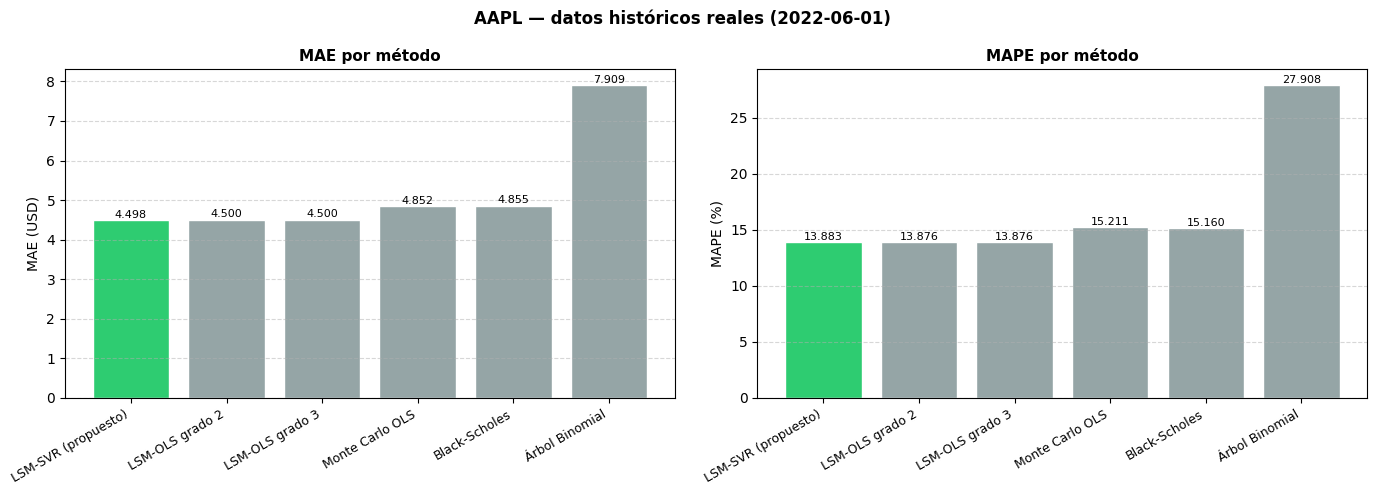

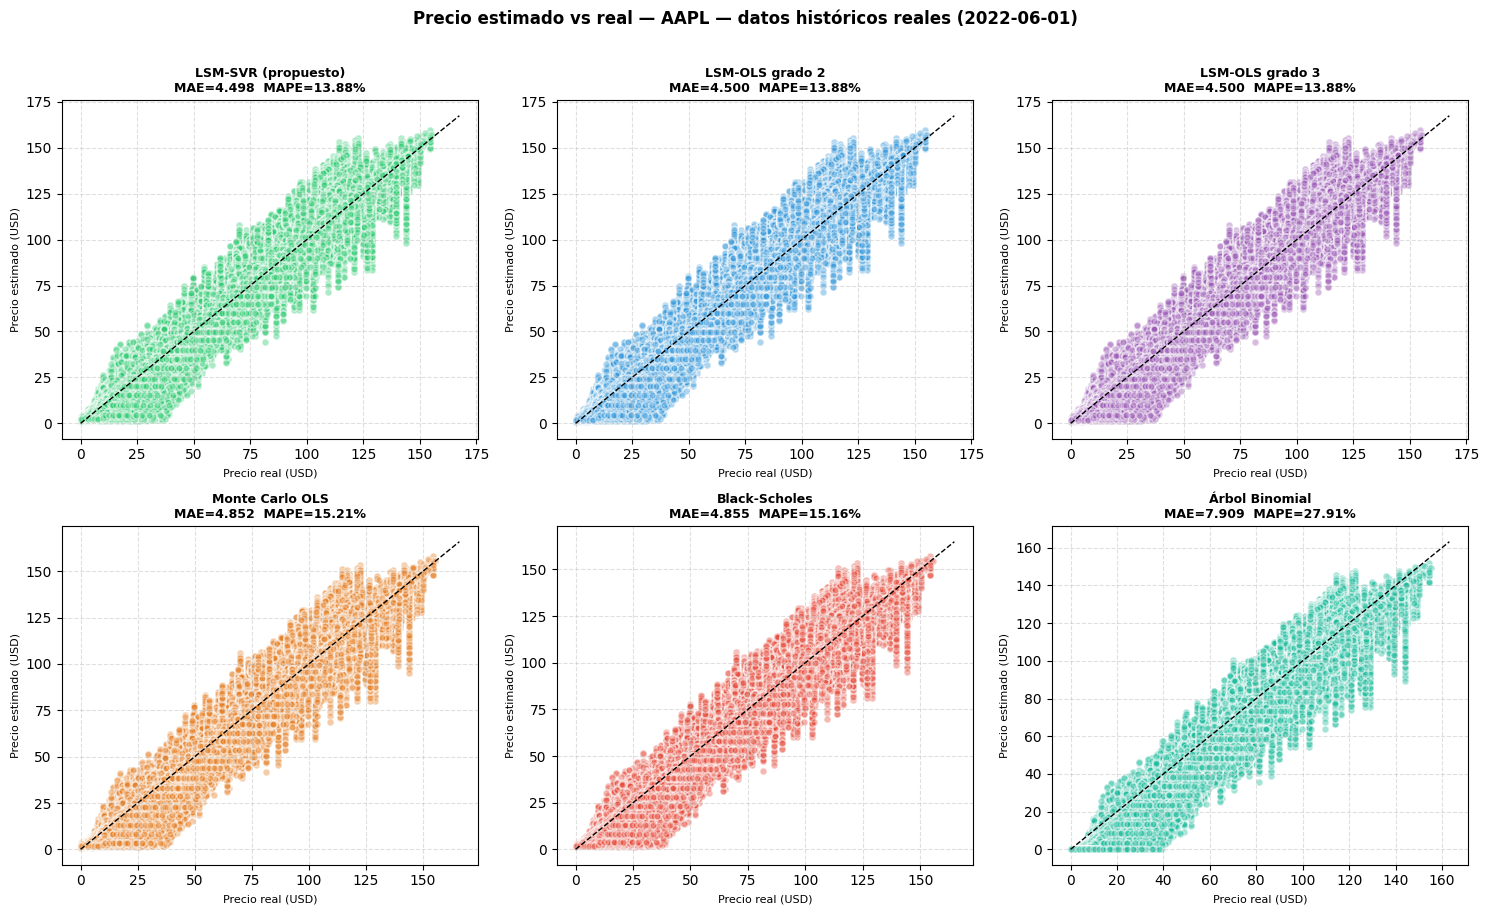

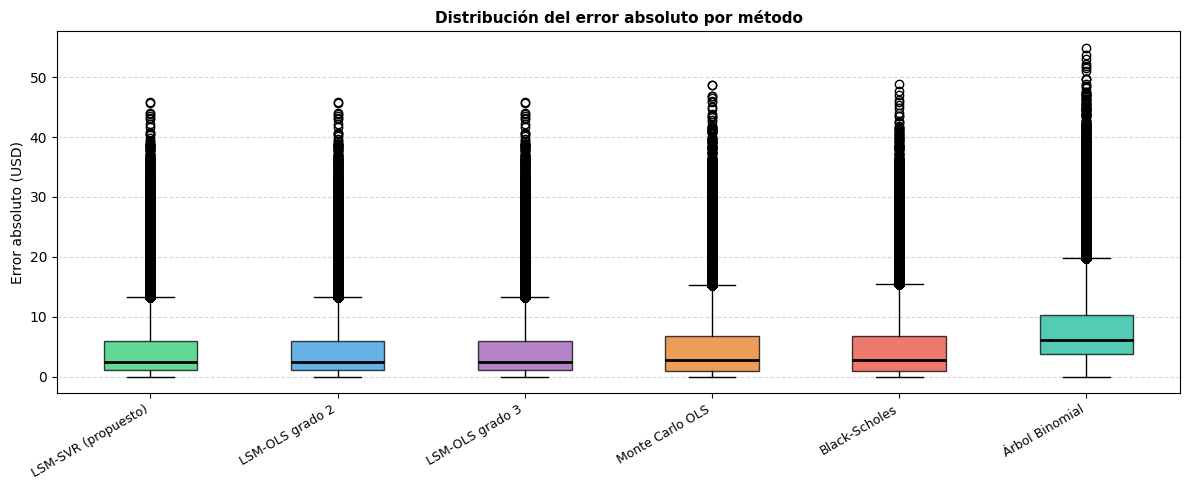

In [33]:
# PASO 5: Métricas y gráficas
metodos = ['optionPrice','lsp2_price','lsp3_price',
           'monte_carlo_price','black_scholes_price','binomial_price']
etiquetas = {
    'optionPrice':         'LSM-SVR (propuesto)',
    'lsp2_price':          'LSM-OLS grado 2',
    'lsp3_price':          'LSM-OLS grado 3',
    'monte_carlo_price':   'Monte Carlo OLS',
    'black_scholes_price': 'Black-Scholes',
    'binomial_price':      'Árbol Binomial'
}

df_kag_ev, resumen_kag = calcular_metricas(df_kag_v, metodos, etiquetas)
print(f'=== {SYMBOL} | {FECHA_VALUACION} | vol hist {VENTANA_VOL}d ===')
print(f'Opciones: {len(df_kag_v):,}')
print(resumen_kag.to_string())

graficar_comparativa(df_kag_ev, metodos, etiquetas,
                     titulo=f'{SYMBOL} — datos históricos reales ({FECHA_VALUACION})')


### Uso — portafolio multi-ticker

In [ ]:
# Corre sobre los 4 tickers disponibles en Kaggle
# Descomenta para ejecutar (tarda varios minutos)

# TICKERS_KAGGLE = ['AAPL', 'SPY', 'QQQ', 'TSLA']
# resultados_kag = {}
#
# for sym in TICKERS_KAGGLE:
#     print(f'\n--- {sym} ---')
#     df_t    = cargar_kaggle_options(sym)
#     df_t_f  = filtrar_kaggle(df_t, START_DATE, END_DATE, OPTION_TYPE,
#                              usar_vol_historica=True, ventana_vol=VENTANA_VOL)
#     inf_t   = inf_portfolio_historico(sym, FECHA_VALUACION, START_DATE, END_DATE)
#     rr_t    = tasa_libre_riesgo(
#         (pd.to_datetime(FECHA_VALUACION)-pd.Timedelta(days=30)).strftime('%Y-%m-%d'),
#         FECHA_VALUACION)
#     df_t_f['cashFlows'] = df_t_f.apply(
#         lambda row: float(condicional(row['symbol'], row['optionType'], row['strike'], inf_t)),
#         axis=1)
#     df_t_v = agregar_valuaciones(df_t_f, T, dt, num_paths, rr_t, inf_t)
#     _, res_t = calcular_metricas(df_t_v, metodos, etiquetas)
#     resultados_kag[sym] = res_t['MAE'].to_dict()
#
# df_multi = pd.DataFrame(resultados_kag).T
# df_multi.index.name = 'Ticker'
# print('\n=== MAE por ticker y método (datos históricos reales) ===')
# print(df_multi.to_string())


## 4. Variables Globales (análisis con yfinance)

In [34]:
T         = 1        # Horizonte: 1 año
dt        = 1 / 100  # Paso de tiempo
num_paths = 100      # Trayectorias

start_date   = '2023-01-01'
end_date     = '2026-12-01'
rateRiskFree = tasa_libre_riesgo(start_date, end_date)
print(f'Tasa libre de riesgo: {rateRiskFree:.4f} ({rateRiskFree*100:.2f}%)')


Tasa libre de riesgo: 0.0456 (4.56%)


## 5. Prueba con una sola acción (AAPL) — yfinance

In [35]:
portfolio_single = 'AAPL'
inf_portfolio = tasa_ret_anual_precio_act(portfolio_single, start_date, end_date)
print(inf_portfolio)


  symbol          S0        mu
0   AAPL  308.820007  0.273286


In [ ]:
# PASO 4: cashFlows y valuación con todos los métodos
df_kag_f['cashFlows'] = df_kag_f.apply(
    lambda row: float(
        condicional(
            row['symbol'],
            row['optionType'],
            row['strike'],
            inf_kag
        )
    ),
    axis=1
)

df_kag_v = agregar_valuaciones(
    df_kag_f,
    T,
    dt,
    num_paths,
    rateRF_kag,
    inf_kag,
    graphics=False
)

cols_res = ['lastTradeDate','expirationDate','symbol','optionType','strike','impliedVolatility','lastPrice','optionPrice','lowerInterval',
    'upperInterval','black_scholes_price','monte_carlo_price','binomial_price','lsp2_price','lsp3_price']

df_kag_v[cols_res].head(10)

In [38]:
df_single = obtener_opciones(portfolio_single, start_date, end_date, inf_portfolio)
df_single = df_single[(df_single['optionType']=='calls') &
                       (df_single['inTheMoney']==True)].tail(1).reset_index(drop=True)

df_single['cashFlows'] = df_single.apply(
    lambda row: float(condicional(row['symbol'], row['optionType'], row['strike'], inf_portfolio)),
    axis=1)

df_single = agregar_valuaciones(df_single, T, dt, num_paths, rateRiskFree, inf_portfolio, graphics=True)

cols_res = ['lastTradeDate','expirationDate','symbol','optionType','strike','impliedVolatility','lastPrice','optionPrice','lowerInterval',
    'upperInterval','black_scholes_price','monte_carlo_price','binomial_price','lsp2_price','lsp3_price']

df_single[cols_res]


KeyError: 'expirationDate'

## 6. Portafolio FAANG — yfinance

In [41]:
portfolio = ['META', 'AMZN', 'AAPL', 'NFLX', 'GOOG']
inf_portfolio = tasa_ret_anual_precio_act(portfolio, start_date, end_date)
print(inf_portfolio)


  symbol          S0        mu
0   META  610.260010  0.473567
1   AMZN  266.320007  0.336133
2   AAPL  308.820007  0.273286
3   NFLX   88.599998  0.326475
4   GOOG  379.380005  0.430461


In [42]:
df = obtener_opciones(portfolio, start_date, end_date, inf_portfolio)
df['cashFlows'] = df.apply(
    lambda row: float(condicional(row['symbol'], row['optionType'], row['strike'], inf_portfolio)),
    axis=1)

df = agregar_valuaciones(df, T, dt, num_paths, rateRiskFree, inf_portfolio, graphics=False)
print('Tiempos de ejercicio únicos:', df['optionValuation'].unique())
df[cols_res].head(10)


ZeroDivisionError: division by zero

## 7. Análisis: opciones con mayor y menor diferencia LSM vs Monte Carlo

In [ ]:
df['price_diff'] = df['optionPrice'] - df['monte_carlo_price']

contract_symbols = {}
for symbol in portfolio:
    sdf = df[df['symbol'] == symbol]
    contract_symbols[symbol] = {
        'max': sdf.loc[sdf['price_diff'].idxmax(), 'contractSymbol'],
        'min': sdf.loc[sdf['price_diff'].idxmin(), 'contractSymbol']
    }

all_contracts = [c for v in contract_symbols.values() for c in v.values()]
final_df      = df[df['contractSymbol'].isin(all_contracts)].copy()

var_base = ['contractSymbol','lastTradeDate','strike','lastPrice',
            'impliedVolatility','optionType','symbol','shortDate','inTheMoney']
df_graficas = final_df[var_base].copy()
df_graficas['cashFlows'] = df_graficas.apply(
    lambda row: float(condicional(row['symbol'], row['optionType'], row['strike'], inf_portfolio)),
    axis=1)

df_graficas = agregar_valuaciones(
    df_graficas, T, dt, num_paths, rateRiskFree, inf_portfolio, graphics=True)
df_graficas[cols_res]


## 8. Comparativa de métodos — portafolio FAANG (yfinance)

| Método | Tipo opción | Regresión |
|---|---|---|
| `optionPrice` | Americana | SVR kernel RBF — **propuesto** |
| `lsp2_price` | Americana | OLS polinomio grado 2 |
| `lsp3_price` | Americana | OLS polinomio grado 3 |
| `monte_carlo_price` | Americana | OLS cuadrático |
| `black_scholes_price` | **Europea** | — |
| `binomial_price` | Americana | — |


In [ ]:
metodos = ['optionPrice','lsp2_price','lsp3_price',
           'monte_carlo_price','black_scholes_price','binomial_price']
etiquetas = {
    'optionPrice':         'LSM-SVR (propuesto)',
    'lsp2_price':          'LSM-OLS grado 2',
    'lsp3_price':          'LSM-OLS grado 3',
    'monte_carlo_price':   'Monte Carlo OLS',
    'black_scholes_price': 'Black-Scholes',
    'binomial_price':      'Árbol Binomial'
}

df_eval, resumen = calcular_metricas(df, metodos, etiquetas)
print('=== Resumen global — portafolio FAANG ===')
print(resumen.to_string())


In [ ]:
# MAE por símbolo
resumen_sym = {}
for sym in portfolio:
    sub = df_eval[df_eval['symbol']==sym]
    resumen_sym[sym] = {etiquetas[c]: round(sub[f'ae_{c}'].mean(),4) for c in metodos}
df_sym = pd.DataFrame(resumen_sym).T
df_sym.index.name = 'Símbolo'
print('=== MAE por símbolo ==='); print(df_sym.to_string())


In [ ]:
graficar_comparativa(df_eval, metodos, etiquetas, titulo='Portafolio FAANG — yfinance')

# Barras agrupadas por símbolo
cmap  = ['#2ecc71','#3498db','#9b59b6','#e67e22','#e74c3c','#1abc9c']
x, width = np.arange(len(portfolio)), 0.13
fig, ax = plt.subplots(figsize=(14, 6))
for idx, (col, color) in enumerate(zip(metodos, cmap)):
    vals   = [df_eval[df_eval['symbol']==sym][f'ae_{col}'].mean() for sym in portfolio]
    offset = (idx - len(metodos)/2 + 0.5) * width
    ax.bar(x+offset, vals, width, label=etiquetas[col], color=color, edgecolor='white', linewidth=0.6)
ax.set_title('MAE por símbolo y método — FAANG', fontsize=12, fontweight='bold')
ax.set_ylabel('MAE (USD)'); ax.set_xticks(x); ax.set_xticklabels(portfolio, fontsize=11)
ax.legend(fontsize=8, framealpha=0.9); ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout(); plt.show()
